In [3]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import keras

from matplotlib import pyplot as plt
from keras import layers, models, regularizers
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from collections import Counter
from imblearn.over_sampling import SMOTE

In [5]:
BATCH_SIZE = 32
IMG_SIZE = (128, 128)

In [6]:
IMAGES_DIR = "../data/images"
MASKS_DIR = "../data/masks/"
CSV_PATH = "../data/GroundTruth.csv"

In [7]:
metadata = pd.read_csv(CSV_PATH)

print(metadata.head())
print(metadata.info())

          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  str    
 1   MEL     10015 non-null  float64
 2   NV      10015 non-null  float64
 3   BCC     10015 non-null  float64
 4   AKIEC   10015 non-null  float64
 5   BKL     10015 non-null  float64
 6   DF      10015 non-null  float64
 7   VASC    10015 non-null  float64
dtypes: float64(7), str(1)
memory usage: 626.1 KB
None


#### CLASSES

As sete classes utilizadas são:

- **MEL:** Melanoma
- **NV:** Nevos Melanocíticos
- **BCC:** Carcinoma Basocelular
- **AKIEC:** Queratose Actínica
- **BKL:** Queratose Benigna
- **DF:** Dermatofibroma
- **VASC:** Lesão Vascular

São criados dois dicionários:

- `class_code`: nome da classe para número
- `class_name`: número para nome da classe

In [8]:
classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

class_code = {label: code for code, label in enumerate(classes)}
class_name = {code: label for code, label in enumerate(classes)}

print(class_code)
print(class_name)

{'MEL': 0, 'NV': 1, 'BCC': 2, 'AKIEC': 3, 'BKL': 4, 'DF': 5, 'VASC': 6}
{0: 'MEL', 1: 'NV', 2: 'BCC', 3: 'AKIEC', 4: 'BKL', 5: 'DF', 6: 'VASC'}


### CRIAÇÃO DOS RÓTULOS CODIFICADOS

A função abaixo lê os nomes das imagens disponíveis na pasta `data/images`, cruza esses nomes com o arquivo `GroundTruth.csv` e transforma a classe de cada imagem em um valor inteiro.

Esse formato é necessário porque a CNN será treinada com `SparseCategoricalCrossEntropy`.

In [9]:
def get_coded_labels(directory, metadata, class_code):
    image_names = [
        x.rsplit(".", 1)[0]
        for x in os.listdir(directory)
        if x.lower().endswith((".jpg", ",jpeg", ".png"))
    ]

    image_df = pd.DataFrame({"image": sorted(image_names)})

    merged = image_df.merge(metadata, on="image", how="inner")

    coded_labels = merged[classes].idxmax(axis=1).map(lambda x: class_code[x])

    return list(coded_labels)

### CRIAÇÃO DO DATASET

O dataset é criado redimensionando todas as imagens, associando cada imagem ao seu rótulo numérico e convertendo-as em um objeto `tf.data.Dataset`.

In [10]:
dataset = keras.utils.image_dataset_from_directory(
    directory=IMAGES_DIR,
    labels=get_coded_labels(IMAGES_DIR, metadata, class_code),
    batch_size=None,
    label_mode="int",
    shuffle=True,
    image_size=IMG_SIZE
)

Found 10015 files belonging to 7 classes.


In [11]:
train_ds, test_ds = keras.utils.split_dataset(
    dataset,
    left_size=0.8,
    shuffle=True,
    seed=42
)

### BALANCEAMENTO COM SMOTE E DATA AUGMENTATION

Após a divisão entre treino e teste, o SMOTE foi aplicado somente ao conjunto de treino, com o objetivo de balancear a quantidade de amostras entre as classes.

Em seguida, o conjunto de treino balanceado foi convertido novamente para `tf.data.Dataset`, embaralhado, dividido em batches e submetido ao Data Augmentation durante o treinamento.

In [12]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images, labels):
    for layer in data_augmentation_layers:
        images = layer(images, training=True)
    
    return images, labels


In [13]:

def dataset_to_numpy(ds):
    images_list = []
    labels_list = []

    for image, label in ds:
        images_list.append(image.numpy().astype("float32"))
        labels_list.append(label.numpy())

    X = np.stack(images_list)
    y = np.array(labels_list, dtype=np.int32)

    return X, y

X_train, y_train = dataset_to_numpy(train_ds)

In [14]:
print("Distribuição original do treino:")
print(Counter(y_train))

Distribuição original do treino:
Counter({np.int32(1): 5340, np.int32(4): 899, np.int32(0): 897, np.int32(2): 411, np.int32(3): 256, np.int32(6): 112, np.int32(5): 97})


In [15]:
original_train_label_counts = pd.Series(y_train).value_counts().sort_index()
original_train_label_counts.index = [class_name[i] for i in original_train_label_counts.index]

n_samples, height, width, channels = X_train.shape

X_train_flat = X_train.reshape(n_samples, -1)

smote = SMOTE(random_state=42, k_neighbors=3)

X_train_smote_flat, y_train_smote = smote.fit_resample(
    X_train_flat,
    y_train
)

X_train_smote = X_train_smote_flat.reshape(-1, height, width, channels)
X_train_smote = np.clip(X_train_smote, 0, 255).astype("float32")
y_train_smote = y_train_smote.astype("int32")

In [16]:
print("\nDistribuição do treino após SMOTE:")
print(Counter(y_train_smote))


Distribuição do treino após SMOTE:
Counter({np.int32(1): 5340, np.int32(4): 5340, np.int32(6): 5340, np.int32(2): 5340, np.int32(5): 5340, np.int32(3): 5340, np.int32(0): 5340})


In [17]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train_smote, y_train_smote))

train_ds = train_ds.shuffle(
    buffer_size=len(y_train_smote),
    seed=42
)

train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

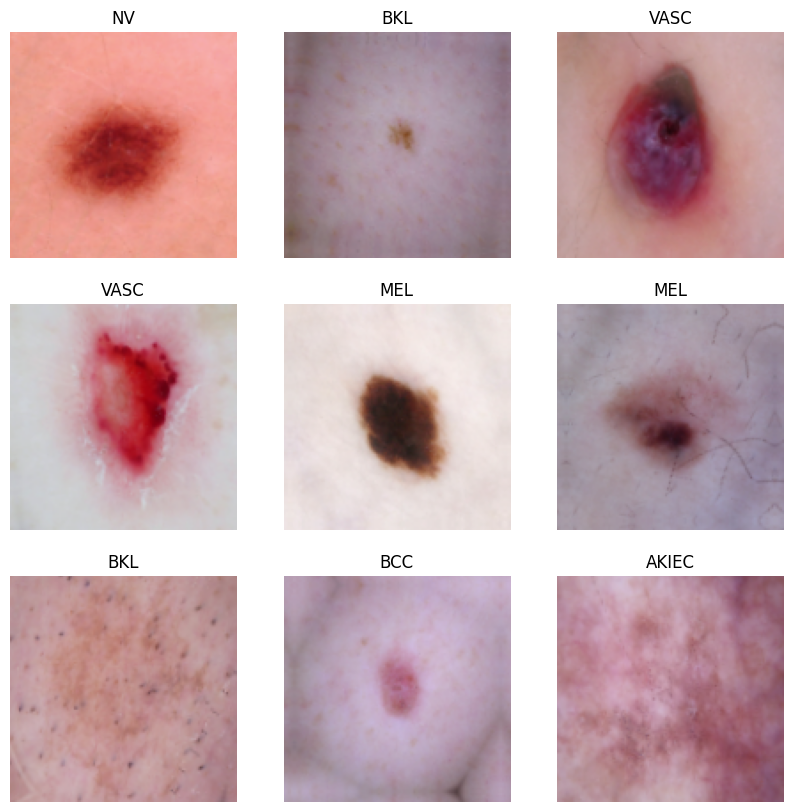

In [18]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        image = tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8)
        plt.imshow(image)

        plt.title(class_name[int(labels[i].numpy())])
        plt.axis("off")

plt.show()

Quantidade de imagens no conjunto de treino após SMOTE: 37380


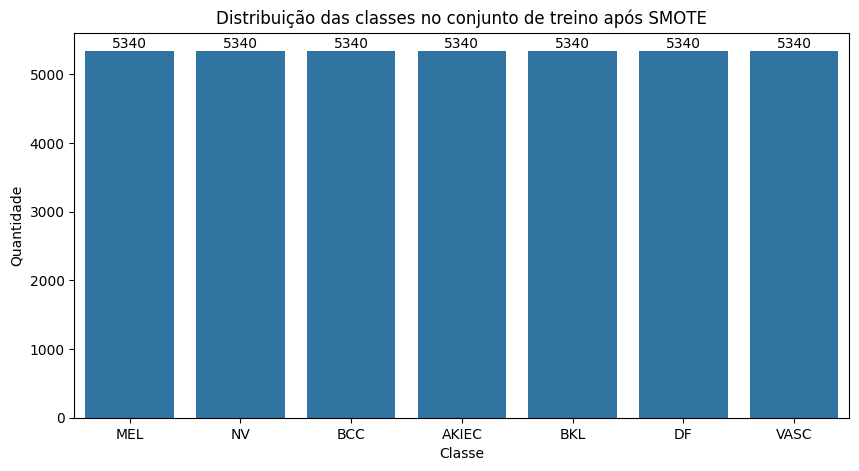

MEL      5340.0
NV       5340.0
BCC      5340.0
AKIEC    5340.0
BKL      5340.0
DF       5340.0
VASC     5340.0
dtype: object


In [19]:
train_label_df = pd.DataFrame(columns=classes)

for images, labels in train_ds.as_numpy_iterator():
    label_array = np.zeros((len(labels), len(classes)))

    for i, label in enumerate(labels):
        label_array[i, int(label)] = 1

    batch_df = pd.DataFrame(label_array, columns=classes)
    train_label_df = pd.concat([train_label_df, batch_df], ignore_index=True)

card = len(train_label_df)

print("Quantidade de imagens no conjunto de treino após SMOTE:", card)

label_counts = train_label_df.sum()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribuição das classes no conjunto de treino após SMOTE")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

print(label_counts)

In [20]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),

    layers.Dense(len(classes))
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,951 (980.28 KB)

 Trainable params: 250,247 (977.53 KB)

 Non-trainable params: 704 (2.75 KB)

In [21]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [22]:
print("Distribuição final usada no treinamento:")
print(label_counts)

Distribuição final usada no treinamento:
MEL      5340.0
NV       5340.0
BCC      5340.0
AKIEC    5340.0
BKL      5340.0
DF       5340.0
VASC     5340.0
dtype: object


In [23]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


In [24]:
history = model.fit(
    train_ds,
    epochs=200,
    validation_data=test_ds,
    callbacks=[early_stopping]
)

Epoch 1/200
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 302s 257ms/step - accuracy: 0.4951 - loss: 1.4436 - val_accuracy: 0.5397 - val_loss: 1.2866
Epoch 2/200
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 350s 299ms/step - accuracy: 0.6113 - loss: 1.1520 - val_accuracy: 0.6121 - val_loss: 1.0692
Epoch 3/200
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 338s 289ms/step - accuracy: 0.6560 - loss: 1.0306 - val_accuracy: 0.5532 - val_loss: 1.2884
Epoch 4/200
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 359s 307ms/step - accuracy: 0.6820 - loss: 0.9558 - val_accuracy: 0.6211 - val_loss: 1.0197
Epoch 5/200
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 391s 334ms/step - accuracy: 0.7012 - loss: 0.9004 - val_accuracy: 0.6151 - val_loss: 1.0936
Epoch 6/200
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 370s 317ms/step - accuracy: 0.7201 - loss: 0.8502 - val_accuracy: 0.6490 - val_loss: 0.9751
Epoch 7/200
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 362s 309ms/step - accuracy: 0.7346 - loss: 0.8112 - val_accuracy: 0.6995 - val_loss: 0.8811
Epoch 8/200
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 392s 336ms/s

In [7]:
epochs = len(history.history["loss"])

comparison_df = pd.DataFrame({
    "Classe": label_counts.index.tolist(),
    "Imagens no treino após SMOTE": label_counts.values,
    "Exposições com SMOTE + DA durante o treinamento": (label_counts * epochs).values
})

comparison_df_melted = comparison_df.melt(
    id_vars="Classe",
    var_name="Tipo",
    value_name="Quantidade"
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=comparison_df_melted,
    x="Classe",
    y="Quantidade",
    hue="Tipo"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Comparação entre imagens após SMOTE e exposições durante o treinamento com Data Augmentation")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.legend(title="")
plt.show()

NameError: name 'history' is not defined

In [8]:
"history" in globals()

False

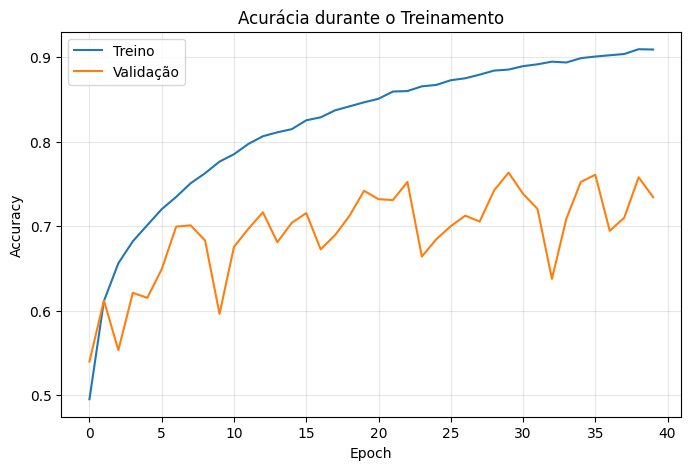

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Acurácia durante o Treinamento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

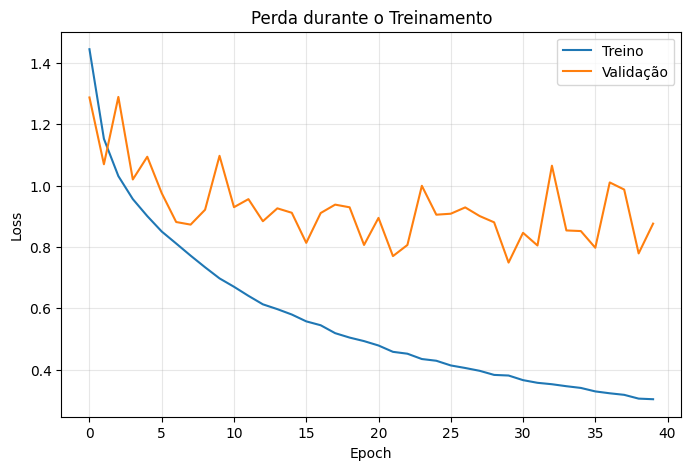

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Perda durante o Treinamento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
probability_model = tf.keras.Sequential([
    model,
    layers.Softmax()
])

In [29]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = probability_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

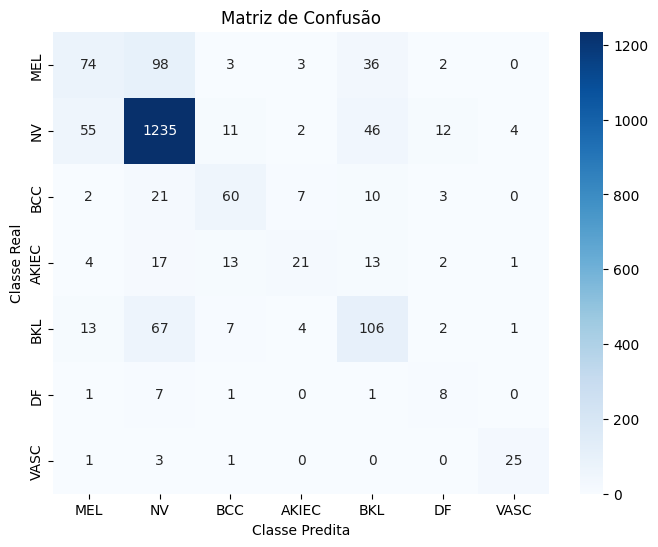

In [30]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues"
)

plt.title("Matriz de Confusão")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.show()

In [31]:
report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
)

print("Relatório de Classificação:\n")
print(report)

Relatório de Classificação:

              precision    recall  f1-score   support

         MEL     0.4933    0.3426    0.4044       216
          NV     0.8529    0.9048    0.8781      1365
         BCC     0.6250    0.5825    0.6030       103
       AKIEC     0.5676    0.2958    0.3889        71
         BKL     0.5000    0.5300    0.5146       200
          DF     0.2759    0.4444    0.3404        18
        VASC     0.8065    0.8333    0.8197        30

    accuracy                         0.7634      2003
   macro avg     0.5887    0.5619    0.5641      2003
weighted avg     0.7512    0.7634    0.7535      2003



In [32]:
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print("MÉTRICAS GERAIS DO MODELO")
print(f"\nAccuracy: {accuracy:.4f}")
print(f"\nMacro Average:")
print(f"  Precision: {precision_macro:.4f}")
print(f"  Recall: {recall_macro:.4f}")
print(f"  F1-Score: {f1_macro:.4f}")
print(f"\nWeighted Average:")
print(f"  Precision: {precision_weighted:.4f}")
print(f"  Recall: {recall_weighted:.4f}")
print(f"  F1-Score: {f1_weighted:.4f}")

MÉTRICAS GERAIS DO MODELO

Accuracy: 0.7634

Macro Average:
  Precision: 0.5887
  Recall: 0.5619
  F1-Score: 0.5641

Weighted Average:
  Precision: 0.7512
  Recall: 0.7634
  F1-Score: 0.7535


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


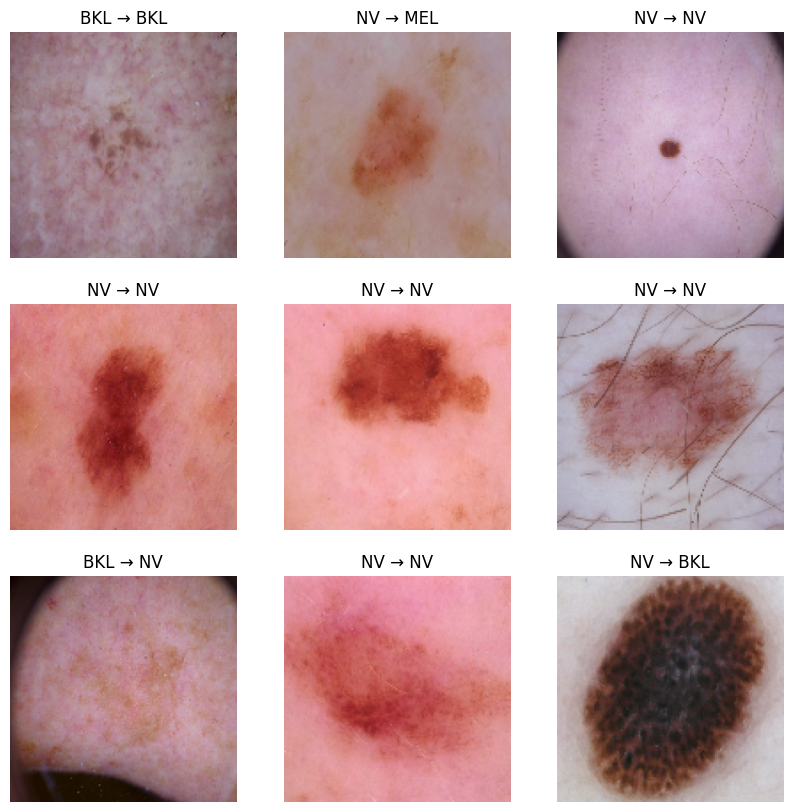

In [33]:
plt.figure(figsize=(10, 10))

for images, labels in test_ds.take(1):
    predictions = probability_model.predict(images)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        image = tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8)
        plt.imshow(image)

        true_label = class_name[int(labels[i].numpy())]
        pred_label = class_name[int(np.argmax(predictions[i]))]

        plt.title(f"{true_label} → {pred_label}")
        plt.axis("off")

plt.show()

In [34]:
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]
final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]

print("\nDiagnóstico final:")
print(f"Train accuracy: {final_train_acc:.4f}")
print(f"Val accuracy: {final_val_acc:.4f}")
print(f"Train loss: {final_train_loss:.4f}")
print(f"Val loss: {final_val_loss:.4f}")


Diagnóstico final:
Train accuracy: 0.9091
Val accuracy: 0.7344
Train loss: 0.3043
Val loss: 0.8759
